# **Data augmentation**

In [1]:

from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.v2 as T
import torchvision.transforms as T_base
import numpy as np
import plotly.graph_objects as go
import plotly.subplots as sp
from plotly.subplots import make_subplots
import random
import copy
from tqdm import tqdm
from numpy.random import MT19937
from numpy.random import RandomState
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

import torch
from torchvision.transforms import v2

plt.rcParams["savefig.bbox"] = 'tight'

# if you change the seed, make sure that the randomly-applied transforms
# properly show that the image can be both transformed and *not* transformed!
torch.manual_seed(0)

# If you're trying to run that on Colab, you can download the assets and the
# helpers from https://github.com/pytorch/vision/tree/main/gallery/
from helpers import plot


In [3]:
image_path = "robot.jpg"
orig_img = Image.open(image_path)

## Geometric Transforms
Geometric image transformation refers to the process of altering the geometric properties of an image,
such as its shape, size, orientation, or position.
It involves applying mathematical operations to the image pixels or coordinates to achieve the desired transformation.

### Pad
The :class:`~torchvision.transforms.Pad` transform
(see also :func:`~torchvision.transforms.functional.pad`)
pads all image borders with some pixel values.



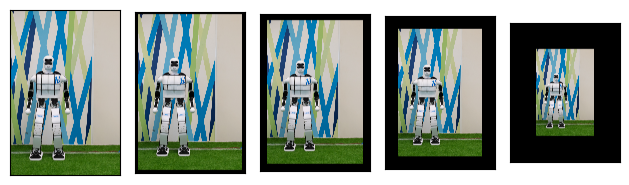

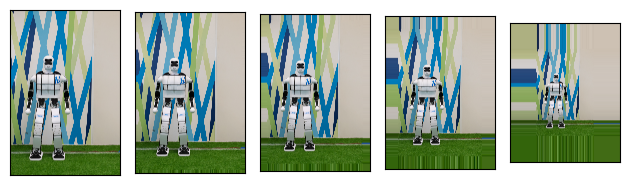

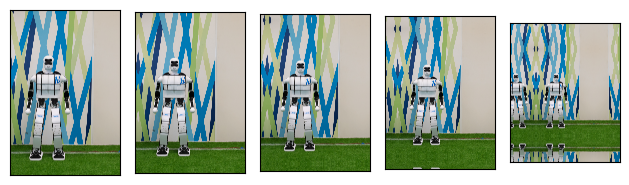

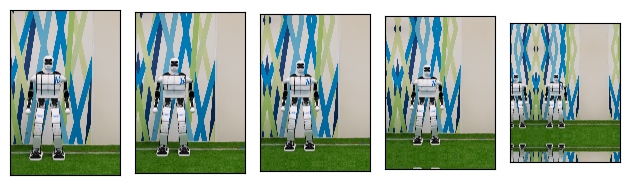

In [4]:
padding_types = ["constant", "edge", "reflect", "symmetric"]
for type in padding_types:
    padded_imgs = [v2.Pad(padding=padding, fill=[0, 0, 0], padding_mode=type)(orig_img) for padding in (100, 250, 500, 1500)]
    plot([orig_img] + padded_imgs)


### Resize
The :class:`~torchvision.transforms.Resize` transform
(see also :func:`~torchvision.transforms.functional.resize`)
resizes an image.



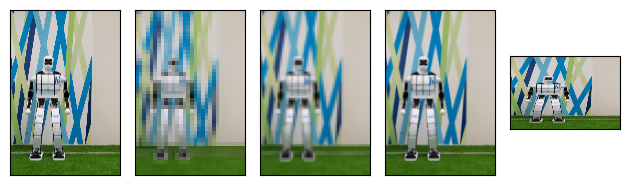

In [5]:
resized_imgs = [v2.Resize(size=size)(orig_img) for size in (30, 50, 100, orig_img.size)]
plot([orig_img] + resized_imgs)

### CenterCrop
The :class:`~torchvision.transforms.CenterCrop` transform
(see also :func:`~torchvision.transforms.functional.center_crop`)
crops the given image at the center.



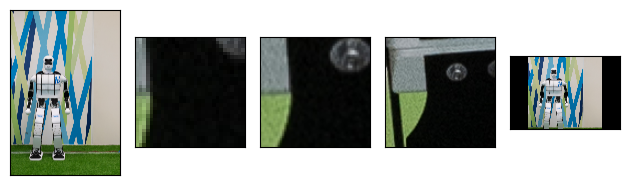

In [6]:
center_crops = [v2.CenterCrop(size=size)(orig_img) for size in (30, 50, 100, orig_img.size)]
plot([orig_img] + center_crops)

### FiveCrop
The :class:`~torchvision.transforms.FiveCrop` transform
(see also :func:`~torchvision.transforms.functional.five_crop`)
crops the given image into four corners and the central crop.



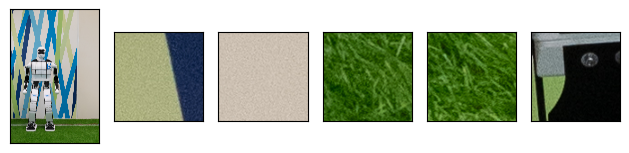

In [7]:
(top_left, top_right, bottom_left, bottom_right, center) = v2.FiveCrop(size=(100, 100))(orig_img)
plot([orig_img] + [top_left, top_right, bottom_left, bottom_right, center])

### RandomPerspective
The :class:`~torchvision.transforms.RandomPerspective` transform
(see also :func:`~torchvision.transforms.functional.perspective`)
performs random perspective transform on an image.



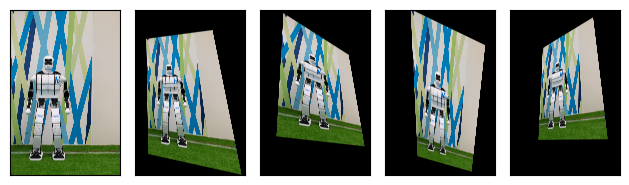

In [8]:
perspective_transformer = v2.RandomPerspective(distortion_scale=0.6, p=1.0)
perspective_imgs = [perspective_transformer(orig_img) for _ in range(4)]
plot([orig_img] + perspective_imgs)

### RandomRotation
The :class:`~torchvision.transforms.RandomRotation` transform
(see also :func:`~torchvision.transforms.functional.rotate`)
rotates an image with random angle.



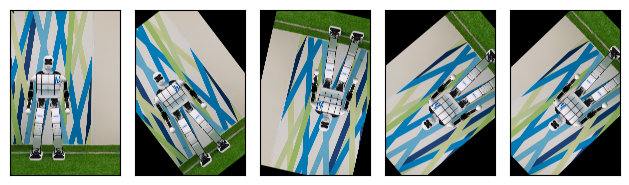

In [9]:
rotater = v2.RandomRotation(degrees=(0, 180))
rotated_imgs = [rotater(orig_img) for _ in range(4)]
plot([orig_img] + rotated_imgs)

### RandomAffine
The :class:`~torchvision.transforms.RandomAffine` transform
(see also :func:`~torchvision.transforms.functional.affine`)
performs random affine transform on an image.



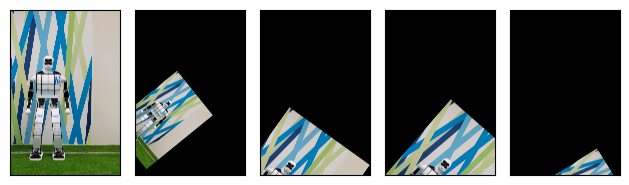

In [10]:
affine_transfomer = v2.RandomAffine(degrees=(30, 70), translate=(0.5, 1), scale=(0.5, 1))
affine_imgs = [affine_transfomer(orig_img) for _ in range(4)]
plot([orig_img] + affine_imgs)

### ElasticTransform
The :class:`~torchvision.transforms.ElasticTransform` transform
(see also :func:`~torchvision.transforms.functional.elastic_transform`)
Randomly transforms the morphology of objects in images and produces a
see-through-water-like effect.



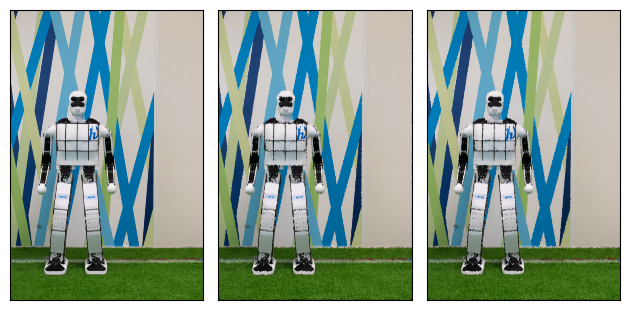

In [11]:
elastic_transformer = v2.ElasticTransform(alpha=250.0)
transformed_imgs = [elastic_transformer(orig_img) for _ in range(2)]
plot([orig_img] + transformed_imgs)

### RandomCrop
The :class:`~torchvision.transforms.RandomCrop` transform
(see also :func:`~torchvision.transforms.functional.crop`)
crops an image at a random location.



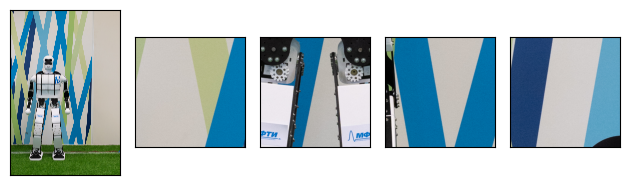

In [12]:
cropper = v2.RandomCrop(size=(512, 512))
crops = [cropper(orig_img) for _ in range(4)]
plot([orig_img] + crops)

### RandomResizedCrop
The :class:`~torchvision.transforms.RandomResizedCrop` transform
(see also :func:`~torchvision.transforms.functional.resized_crop`)
crops an image at a random location, and then resizes the crop to a given
size.



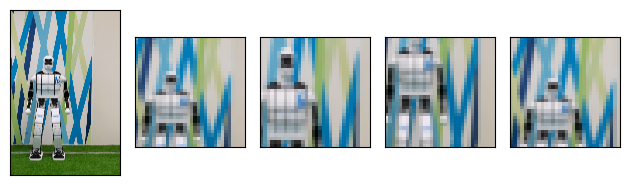

In [13]:
resize_cropper = v2.RandomResizedCrop(size=(32, 32))
resized_crops = [resize_cropper(orig_img) for _ in range(4)]
plot([orig_img] + resized_crops)

## Photometric Transforms
Photometric image transformation refers to the process of modifying the photometric properties of an image,
such as its brightness, contrast, color, or tone.
These transformations are applied to change the visual appearance of an image
while preserving its geometric structure.

Except :class:`~torchvision.transforms.Grayscale`, the following transforms are random,
which means that the same transform
instance will produce different result each time it transforms a given image.

### Grayscale
The :class:`~torchvision.transforms.Grayscale` transform
(see also :func:`~torchvision.transforms.functional.to_grayscale`)
converts an image to grayscale



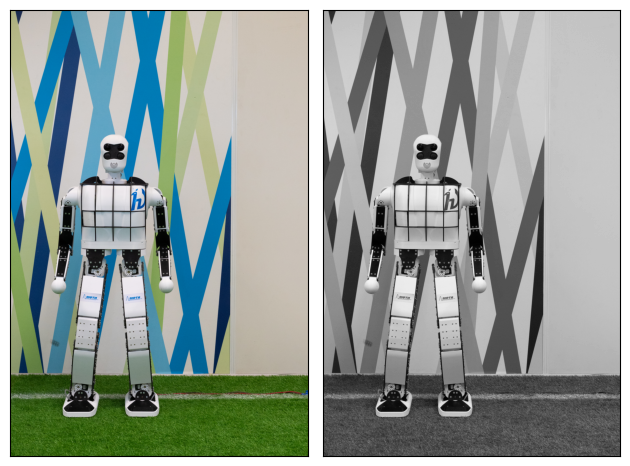

In [14]:
gray_img = v2.Grayscale()(orig_img)
plot([orig_img, gray_img], cmap='gray')

### ColorJitter
The :class:`~torchvision.transforms.ColorJitter` transform
randomly changes the brightness, contrast, saturation, hue, and other properties of an image.



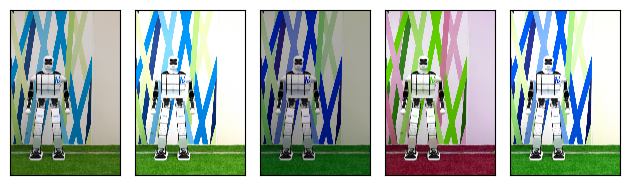

In [15]:
jitter = v2.ColorJitter(brightness=.5, hue=.3)
jittered_imgs = [jitter(orig_img) for _ in range(4)]
plot([orig_img] + jittered_imgs)

### GaussianBlur
The :class:`~torchvision.transforms.GaussianBlur` transform
(see also :func:`~torchvision.transforms.functional.gaussian_blur`)
performs gaussian blur transform on an image.



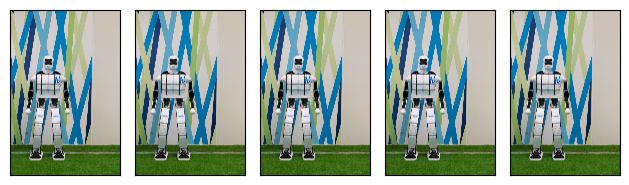

In [16]:
blurrer = v2.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.))
blurred_imgs = [blurrer(orig_img) for _ in range(4)]
plot([orig_img] + blurred_imgs)

### RandomInvert
The :class:`~torchvision.transforms.RandomInvert` transform
(see also :func:`~torchvision.transforms.functional.invert`)
randomly inverts the colors of the given image.



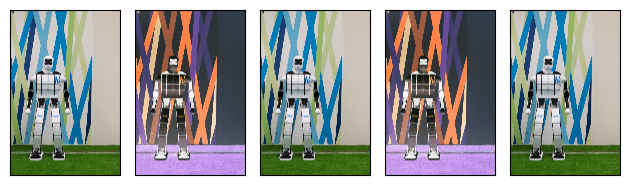

In [17]:
inverter = v2.RandomInvert()
invertered_imgs = [inverter(orig_img) for _ in range(4)]
plot([orig_img] + invertered_imgs)

### RandomPosterize
The :class:`~torchvision.transforms.RandomPosterize` transform
(see also :func:`~torchvision.transforms.functional.posterize`)
randomly posterizes the image by reducing the number of bits
of each color channel.



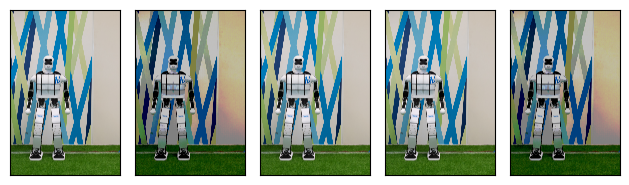

In [18]:
posterizer = v2.RandomPosterize(bits=2)
posterized_imgs = [posterizer(orig_img) for _ in range(4)]
plot([orig_img] + posterized_imgs)

### RandomSolarize
The :class:`~torchvision.transforms.RandomSolarize` transform
(see also :func:`~torchvision.transforms.functional.solarize`)
randomly solarizes the image by inverting all pixel values above
the threshold.



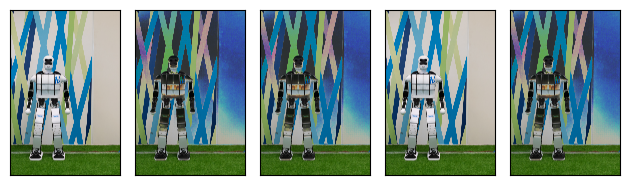

In [19]:
solarizer = v2.RandomSolarize(threshold=192.0)
solarized_imgs = [solarizer(orig_img) for _ in range(4)]
plot([orig_img] + solarized_imgs)

### RandomAdjustSharpness
The :class:`~torchvision.transforms.RandomAdjustSharpness` transform
(see also :func:`~torchvision.transforms.functional.adjust_sharpness`)
randomly adjusts the sharpness of the given image.



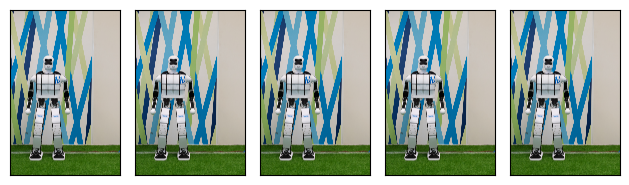

In [20]:
sharpness_adjuster = v2.RandomAdjustSharpness(sharpness_factor=2)
sharpened_imgs = [sharpness_adjuster(orig_img) for _ in range(4)]
plot([orig_img] + sharpened_imgs)

### RandomAutocontrast
The :class:`~torchvision.transforms.RandomAutocontrast` transform
(see also :func:`~torchvision.transforms.functional.autocontrast`)
randomly applies autocontrast to the given image.



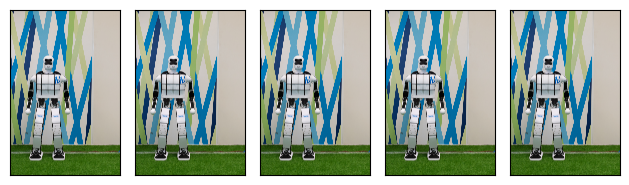

In [21]:
autocontraster = v2.RandomAutocontrast()
autocontrasted_imgs = [autocontraster(orig_img) for _ in range(4)]
plot([orig_img] + autocontrasted_imgs)

### RandomEqualize
The :class:`~torchvision.transforms.RandomEqualize` transform
(see also :func:`~torchvision.transforms.functional.equalize`)
randomly equalizes the histogram of the given image.



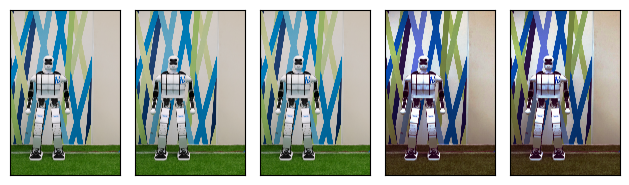

In [22]:
equalizer = v2.RandomEqualize()
equalized_imgs = [equalizer(orig_img) for _ in range(4)]
plot([orig_img] + equalized_imgs)

## Miscellaneous

### Normalize

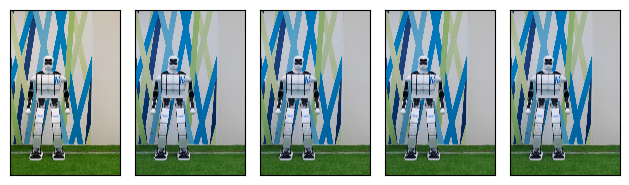

In [23]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize to ImageNet stats
])
normalized_imgs = [transform(orig_img) for _ in range(4)]
pil_normalized_image = [img.permute(1, 2, 0).numpy() for img in normalized_imgs]
plot([orig_img] + pil_normalized_image)

### RandomErasing

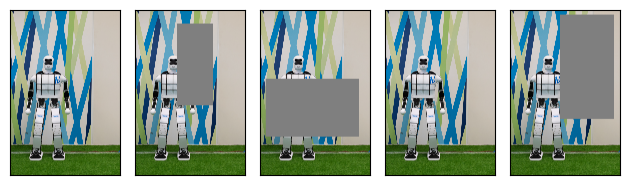

In [24]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomErasing(p=0.8, value=(0.5, 0.5, 0.5))  # Normalize to ImageNet stats
])
erased_imgs = [transform(orig_img) for _ in range(4)]
plot([orig_img] + erased_imgs)

### JPEG
The :class:`~torchvision.transforms.v2.JPEG` transform
(see also :func:`~torchvision.transforms.v2.functional.jpeg`)
applies JPEG compression to the given image with random
degree of compression.



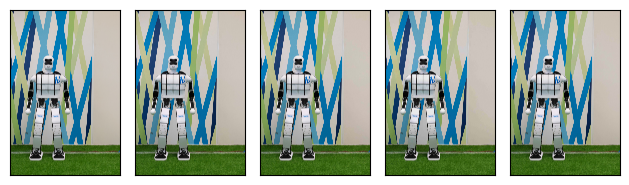

In [25]:
jpeg = v2.JPEG((5, 50))
jpeg_imgs = [jpeg(orig_img) for _ in range(4)]
plot([orig_img] + jpeg_imgs)

## Augmentation Transforms
The following transforms are combinations of multiple transforms,
either geometric or photometric, or both.

### AutoAugment
The :class:`~torchvision.transforms.AutoAugment` transform
automatically augments data based on a given auto-augmentation policy.
See :class:`~torchvision.transforms.AutoAugmentPolicy` for the available policies.



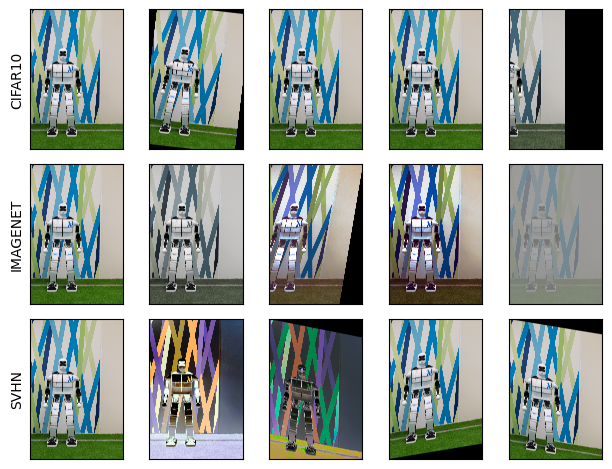

In [26]:
policies = [v2.AutoAugmentPolicy.CIFAR10, v2.AutoAugmentPolicy.IMAGENET, v2.AutoAugmentPolicy.SVHN]
augmenters = [v2.AutoAugment(policy) for policy in policies]
imgs = [
    [augmenter(orig_img) for _ in range(4)]
    for augmenter in augmenters
]
row_title = [str(policy).split('.')[-1] for policy in policies]
plot([[orig_img] + row for row in imgs], row_title=row_title)

### RandAugment
The :class:`~torchvision.transforms.RandAugment` is an alternate version of AutoAugment.



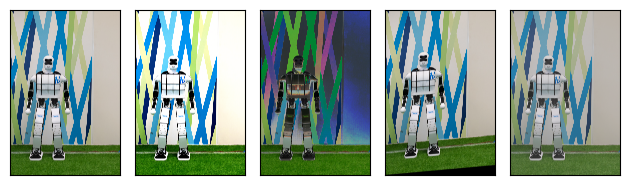

In [27]:
augmenter = v2.RandAugment()
imgs = [augmenter(orig_img) for _ in range(4)]
plot([orig_img] + imgs)

### TrivialAugmentWide
The :class:`~torchvision.transforms.TrivialAugmentWide` is an alternate implementation of AutoAugment.
However, instead of transforming an image multiple times, it transforms an image only once
using a random transform from a given list with a random strength number.



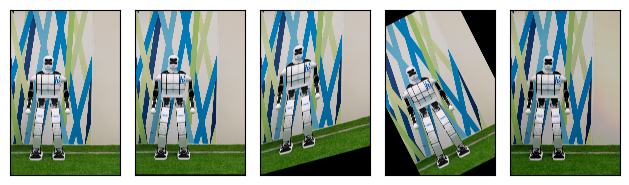

In [28]:
augmenter = v2.TrivialAugmentWide()
imgs = [augmenter(orig_img) for _ in range(4)]
plot([orig_img] + imgs)

### AugMix
The :class:`~torchvision.transforms.AugMix` transform interpolates between augmented versions of an image.



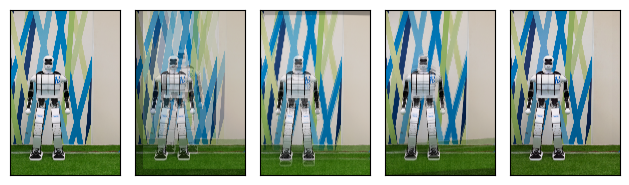

In [29]:
augmenter = v2.AugMix()
imgs = [augmenter(orig_img) for _ in range(4)]
plot([orig_img] + imgs)

## Randomly-applied Transforms

The following transforms are randomly-applied given a probability ``p``.  That is, given ``p = 0.5``,
there is a 50% chance to return the original image, and a 50% chance to return the transformed image,
even when called with the same transform instance!

### RandomHorizontalFlip
The :class:`~torchvision.transforms.RandomHorizontalFlip` transform
(see also :func:`~torchvision.transforms.functional.hflip`)
performs horizontal flip of an image, with a given probability.



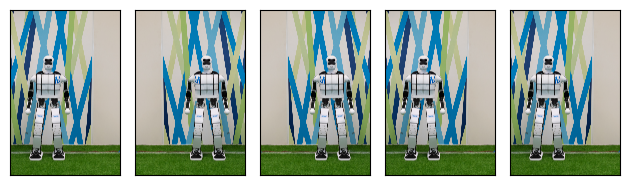

In [30]:
hflipper = v2.RandomHorizontalFlip(p=0.5)
transformed_imgs = [hflipper(orig_img) for _ in range(4)]
plot([orig_img] + transformed_imgs)

### RandomVerticalFlip
The :class:`~torchvision.transforms.RandomVerticalFlip` transform
(see also :func:`~torchvision.transforms.functional.vflip`)
performs vertical flip of an image, with a given probability.



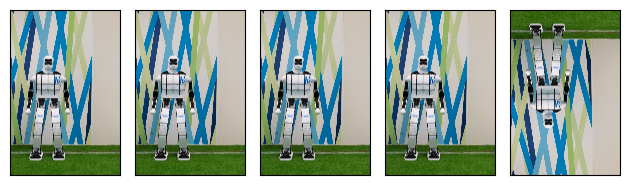

In [31]:
vflipper = v2.RandomVerticalFlip(p=0.5)
transformed_imgs = [vflipper(orig_img) for _ in range(4)]
plot([orig_img] + transformed_imgs)

### RandomApply
The :class:`~torchvision.transforms.RandomApply` transform
randomly applies a list of transforms, with a given probability.



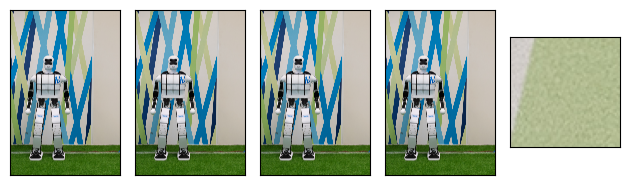

In [32]:
applier = v2.RandomApply(transforms=[v2.RandomCrop(size=(64, 64))], p=0.5)
transformed_imgs = [applier(orig_img) for _ in range(4)]
plot([orig_img] + transformed_imgs)

# **Datasets Examples**

## COCO

- It has more than 328,000 images with keypoint detection, multi-object detection, captioning, and segmentation mask annotations.
- 80 object categories
- 5 captions per image.

https://cocodataset.org/#home

## Cityscape dataset

Cityscape is the dataset to go to when looking for various video sequences recorded from several cites’ street scenes. These images were captured over a long time and in different weather and light conditions. The annotations are for
- 30 classes
- 8 different categories.
- 5 000 annotated images with fine annotations
- 20 000 annotated images with coarse annotations

https://www.cityscapes-dataset.com

## CIFAR-10

- 60000 colour images with 32x32 resolution
- 10 classes

https://www.cs.toronto.edu/~kriz/cifar.html

## MNIST

Database of handwritten digits
- training set of 60 000 examples
- test set of 10000 examples

# Convolutional neural networks

We will work with such visualizers

https://ezyang.github.io/convolution-visualizer/

https://deeplizard.com/resource/pavq7noze2

https://deeplizard.com/resource/pavq7noze4

https://poloclub.github.io/cnn-explainer/

In [ ]:
import torch
from torch import nn

In [ ]:
a = torch.tensor([1.0, 0.0, 0.0], requires_grad=True)
b = torch.tensor([1.0, 0.0, 2.0], requires_grad=True)

In [ ]:
loss = (a @ b) / 2

In [ ]:
loss.backward()

In [ ]:
a.grad, b.grad

(tensor([0.5000, 0.0000, 1.0000]), tensor([0.5000, 0.0000, 0.0000]))

(16, 16, 10).reshape(1690)

(1690,) @ (1690, NUM_CLASSES) = (NUM_CLASSES,) 

(BATCH_SIZE, 1, 28, 28) ->(conv2d) (BATCH_SIZE, 32, 28, 28) ->(relu) (BATCH_SIZE, 32, 28, 28) ->(pool) -> (BATCH_SIZE, 32, 14, 14) ->(conv) -> (BATCH_SIZE, 64, 14, 14)

(BATCH_SIZE, 1690) @ (1690, NUM_CLASSES) = (BATCH_SIZE, NUM_CLASSES) 

(BATCH_SIZE, 128, 4, 4) -> (.view(flatten)) (BATCH_SIZE, 128 * 4 *4) 

(BATCH_SIZE, 128 * 4 *4) @ (128 * 4 * 4, 26)

## 1. Basic arguments of Conv2d

In [ ]:
img = torch.randn(1, 64, 64)

### 1.1 Kernel size

In [ ]:
conv = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3)

What would be the output shape, if we apply this layer to img?

In [ ]:
64 - (3 - 1)

62

In [ ]:
out = conv(img)
out.shape

torch.Size([16, 62, 62])

Output shape became $62 \times 62$ from $64 \times 64$. It is inconvinient, if every convolutional layer will change output shape, without any need for this. Let's add padding.

### 1.2 Padding

In [ ]:
conv = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)

In [ ]:
out = conv(img)
out.shape

torch.Size([16, 64, 64])

So, kernel_size = 3 and padding = 1 is one of the most common combinations, when building CNNs, because
* It has few number of parameters
* Doen't change output shape

Let's try to calculate number of parameters for this layer

In [ ]:
print(1 * 16 * 3 * 3 + 16,  sum(p.numel() for p in conv.parameters()))

160 160


### 1.3 Stride

So, what if we want to reduce image resolution by 2 times, using only Conv2d?

In [ ]:
conv = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1, stride=2)

In [ ]:
out = conv(img)
out.shape

torch.Size([16, 32, 32])

In [ ]:
1 * 16 * 3 * 3 + 16 == sum(p.numel() for p in conv.parameters())

True

Stride dosn't affect number of parameters

### 1.4 Dilation

And what if we want larger receptive filed of layer?

In [ ]:
# Option 1
conv = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, padding=2)
out = conv(img)
out.shape

torch.Size([16, 64, 64])

In [ ]:
print(1 * 16 * 5 * 5 + 16, sum(p.numel() for p in conv.parameters()))

416 416


In [ ]:
conv = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=2, dilation=2)
out = conv(img)
out.shape

torch.Size([16, 64, 64])

In [ ]:
print(1 * 16 * 3 * 3 + 16, sum(p.numel() for p in conv.parameters()))

160 160


Dilation allows to increase receptive filed (roughly) without increasing number of parameters

### 1.5 Bias

Sometimes, you might avoid adding bias for you output (for example if we use batchnorm after that layer). We can disable it.

**Pay attention, many architecrues disable bias**

In [ ]:
conv = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1, bias=False)
out = conv(img)
out.shape

torch.Size([16, 64, 64])

In [ ]:
print(1 * 16 * 3 * 3, sum(p.numel() for p in conv.parameters()))

144 144


### 1.6 Groups

By default, every input channel is connected to every output channel.

In [ ]:
activation = torch.randn(128, 4, 4)

In [ ]:
conv = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
out = conv(activation)
out.shape

torch.Size([256, 4, 4])

In [ ]:
print(128 * 256 * 3 * 3 + 256, sum(p.numel() for p in conv.parameters()))

295168 295168


However, the groups argument allows splitting these connections into subsets, enabling grouped or depthwise convolutions.

In [ ]:
conv = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1, groups=2)
out = conv(activation)
out.shape

torch.Size([256, 4, 4])

In [ ]:
print(2 * (128 // 2 * 256 // 2  * 3 * 3 + 256 // 2), sum(p.numel() for p in conv.parameters()))

147712 147712


Reduced number of parameters twice

### Depthwise convolutions

Sometimes, we want to perform convolution without changing number of channels. And often this is performed deeply in the netowork, when the number of channels is big

In [ ]:
conv = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
out = conv(activation)
out.shape

torch.Size([128, 4, 4])

In [ ]:
print(128 * 128 * 3 * 3 + 128, sum(p.numel() for p in conv.parameters()))

147584 147584


We can use groups = in_channels to perform depthwise convolution

In [ ]:
conv = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1, groups=128)
out = conv(activation)
out.shape

torch.Size([128, 4, 4])

In [ ]:
print(1 * 128 * 3 * 3 + 128, sum(p.numel() for p in conv.parameters()))

1280 1280


So, we perform rough convolution, and reduce number of parameters **100 times**

## 2. Solving image classification on grayscale images

Our task is simple, recognize handwritten digits. We will use MNIST dataset for this tutorial.

<a title="By Josef Steppan [CC BY-SA 4.0 (https://creativecommons.org/licenses/by-sa/4.0)], from Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:MnistExamples.png"><img width="512" alt="MnistExamples" src="https://upload.wikimedia.org/wikipedia/commons/2/27/MnistExamples.png"/></a>

In [ ]:
import torchvision
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.optim as optim

### 2.1 Transforms

In [ ]:
image_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(
        (0.1307,), (0.3081,))
])


### 2.2 Downloading datasets

In [ ]:
train_dataset = torchvision.datasets.MNIST(
    'dataset/',
    train=True,
    download=True,
    transform=image_transform
)
test_dataset = torchvision.datasets.MNIST(
    'dataset/',
    train=False,
    download=True,
    transform=image_transform
)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:18<00:00, 529kB/s] 


Extracting dataset/MNIST\raw\train-images-idx3-ubyte.gz to dataset/MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 144kB/s]


Extracting dataset/MNIST\raw\train-labels-idx1-ubyte.gz to dataset/MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:02<00:00, 609kB/s]


Extracting dataset/MNIST\raw\t10k-images-idx3-ubyte.gz to dataset/MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 170kB/s]

Extracting dataset/MNIST\raw\t10k-labels-idx1-ubyte.gz to dataset/MNIST\raw



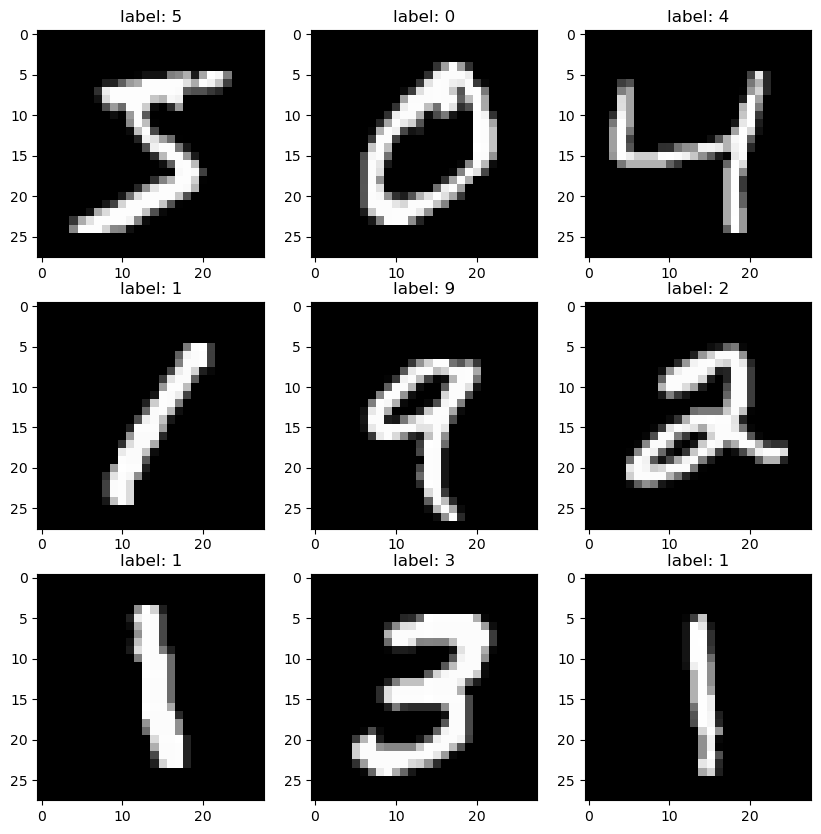

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in zip(range(9), axes.flatten()):
    image, label = train_dataset[i]
    # image.shape = (1, 28, 28), need to remove first axis
    ax.imshow(image[0], cmap='gray')
    ax.set_title(f'label: {label}')

### 2.3 Dataloaders

In [ ]:
batch_size = 256
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True
)

### 2.4 FCN description

In [ ]:
class FCN(nn.Sequential):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28**2, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 10)
        self.relu3 = nn.ReLU()
        self.softmax = nn.Softmax()

### 2.5 CNN description

In [ ]:
class CNN(nn.Sequential):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
        self.relu2 = nn.ReLU()

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2)
        self.relu3 = nn.ReLU()

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3 * 3 * 128, 64)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(64, 10)
        self.softmax = nn.Softmax()

In [ ]:
from torchsummary import summary

summary(FCN(), (1, 28, 28), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                   [-1, 64]          50,240
              ReLU-3                   [-1, 64]               0
            Linear-4                   [-1, 64]           4,160
              ReLU-5                   [-1, 64]               0
            Linear-6                   [-1, 10]             650
              ReLU-7                   [-1, 10]               0
           Softmax-8                   [-1, 10]               0
Total params: 55,050
Trainable params: 55,050
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.21
Estimated Total Size (MB): 0.22
----------------------------------------------------------------


c:\Users\sokol\miniconda3\Lib\site-packages\torch\nn\modules\module.py:1844: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return inner()


In [ ]:
summary(CNN(), (1, 28, 28), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
         MaxPool2d-2           [-1, 32, 14, 14]               0
              ReLU-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
         MaxPool2d-5             [-1, 64, 7, 7]               0
              ReLU-6             [-1, 64, 7, 7]               0
            Conv2d-7            [-1, 128, 7, 7]          73,856
         MaxPool2d-8            [-1, 128, 3, 3]               0
              ReLU-9            [-1, 128, 3, 3]               0
          Flatten-10                 [-1, 1152]               0
           Linear-11                   [-1, 64]          73,792
             ReLU-12                   [-1, 64]               0
           Linear-13                   [-1, 10]             650
          Softmax-14                   

In [ ]:
train_dataset[1][1]

0

### 2.6 Training pipeline

In [ ]:
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    tk0 = tqdm(train_loader, total=int(len(train_loader)))
    counter = 0
    train_loss = 0
    criterion = nn.CrossEntropyLoss()
    for batch_idx, (data, target) in enumerate(tk0):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
        counter += 1
        tk0.set_postfix(loss=(loss.item()*data.size(0) / (counter * train_loader.batch_size)))
    train_loss /= len(train_loader.dataset)
    return train_loss

def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))
    return test_loss

def fit(model, learning_rate, num_epoch, device):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_loss_epochs = []
    test_loss_epochs = []
    for epoch in range(1, num_epoch + 1):
            train_loss = train(model, device, train_loader, optimizer, epoch)
            train_loss_epochs.append(train_loss)
            test_loss = test(model, device, test_loader)
            test_loss_epochs.append(test_loss)
    return train_loss_epochs, test_loss_epochs

In [ ]:
learning_rate = 0.001
num_epoch = 5
device = "cpu"

In [ ]:
torch.manual_seed(0)
model = FCN().to(device)
fcn_train_loss_epochs, fcn_test_loss_epochs = fit(model, learning_rate, num_epoch, device)

  0%|          | 0/235 [00:00<?, ?it/s]

c:\Users\sokol\miniconda3\Lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)



Test set: Average loss: 0.0071, Accuracy: 6785/10000 (68%)



  0%|          | 0/235 [00:00<?, ?it/s]


Test set: Average loss: 0.0068, Accuracy: 7743/10000 (77%)



...


Test set: Average loss: 0.0067, Accuracy: 7811/10000 (78%)



  0%|          | 0/235 [00:00<?, ?it/s]


Test set: Average loss: 0.0067, Accuracy: 7842/10000 (78%)



  0%|          | 0/235 [00:00<?, ?it/s]


Test set: Average loss: 0.0066, Accuracy: 7864/10000 (79%)



In [ ]:
torch.manual_seed(0)
model = CNN().to(device)
cnn_train_loss_epochs, cnn_test_loss_epochs = fit(model, learning_rate, num_epoch, device)


  0%|          | 0/235 [00:00<?, ?it/s]


Test set: Average loss: 0.0067, Accuracy: 7961/10000 (80%)



  0%|          | 0/235 [00:00<?, ?it/s]


Test set: Average loss: 0.0060, Accuracy: 9736/10000 (97%)



  0%|          | 0/235 [00:00<?, ?it/s]


Test set: Average loss: 0.0059, Accuracy: 9829/10000 (98%)



  0%|          | 0/235 [00:00<?, ?it/s]


Test set: Average loss: 0.0059, Accuracy: 9864/10000 (99%)



  0%|          | 0/235 [00:00<?, ?it/s]


Test set: Average loss: 0.0059, Accuracy: 9885/10000 (99%)



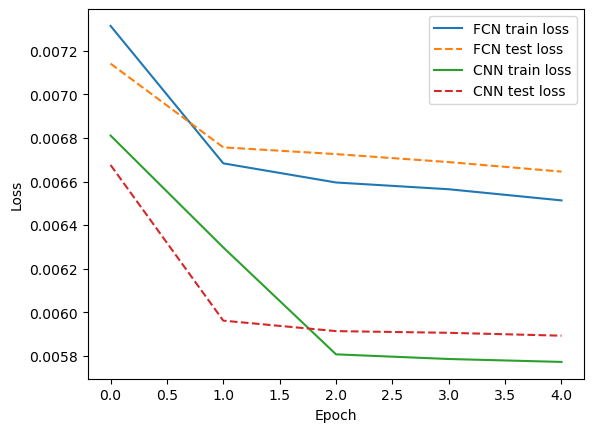

In [ ]:
plt.plot(fcn_train_loss_epochs, label='FCN train loss')
plt.plot(fcn_test_loss_epochs, label='FCN test loss', linestyle='dashed')

plt.plot(cnn_train_loss_epochs, label='CNN train loss')
plt.plot(cnn_test_loss_epochs, label='CNN test loss', linestyle='dashed')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## 3. What if take larger FCN model?

In [ ]:
class LargerFCN(nn.Sequential):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28**2, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 10)
        self.relu3 = nn.ReLU()
        self.softmax = nn.Softmax()

In [ ]:
from torchsummary import summary

summary(LargerFCN(), (1, 28, 28), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 256]         200,960
              ReLU-3                  [-1, 256]               0
            Linear-4                  [-1, 128]          32,896
              ReLU-5                  [-1, 128]               0
            Linear-6                   [-1, 10]           1,290
              ReLU-7                   [-1, 10]               0
           Softmax-8                   [-1, 10]               0
Total params: 235,146
Trainable params: 235,146
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.90
Estimated Total Size (MB): 0.91
----------------------------------------------------------------


c:\Users\sokol\miniconda3\Lib\site-packages\torch\nn\modules\module.py:1844: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return inner()


In [ ]:
torch.manual_seed(0)
model = LargerFCN().to(device)
larger_fcn_train_loss_epochs, larger_fcn_test_loss_epochs = fit(model, learning_rate, num_epoch, device)

  0%|          | 0/235 [00:00<?, ?it/s]


Test set: Average loss: 0.0068, Accuracy: 7385/10000 (74%)



  0%|          | 0/235 [00:00<?, ?it/s]


Test set: Average loss: 0.0068, Accuracy: 7574/10000 (76%)



  0%|          | 0/235 [00:00<?, ?it/s]


Test set: Average loss: 0.0067, Accuracy: 7600/10000 (76%)



  0%|          | 0/235 [00:00<?, ?it/s]


Test set: Average loss: 0.0067, Accuracy: 7638/10000 (76%)



  0%|          | 0/235 [00:00<?, ?it/s]


Test set: Average loss: 0.0067, Accuracy: 7653/10000 (77%)



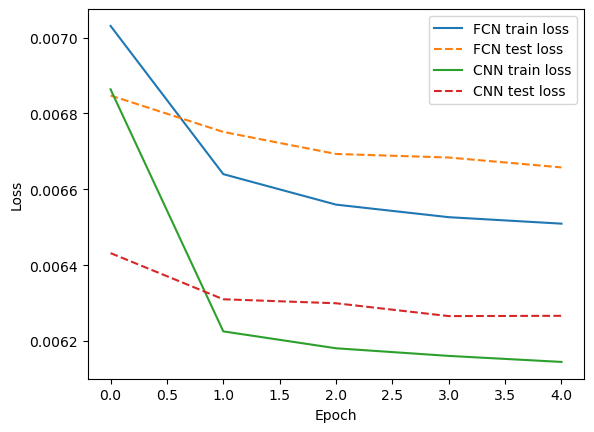

In [ ]:
plt.plot(larger_fcn_train_loss_epochs, label='FCN train loss')
plt.plot(larger_fcn_test_loss_epochs, label='FCN test loss', linestyle='dashed')

plt.plot(cnn_train_loss_epochs, label='CNN train loss')
plt.plot(cnn_test_loss_epochs, label='CNN test loss', linestyle='dashed')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()